In [16]:
from google.colab import files
files.upload()

Saving superstore_cleanedd.csv to superstore_cleanedd (1).csv


{'superstore_cleanedd (1).csv': b'transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,month,month_name,year,age_group\n1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,November,2023,25\xe2\x80\x9334\n2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,February,2023,25\xe2\x80\x9334\n3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,January,2023,45\xe2\x80\x9354\n4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,May,2023,35\xe2\x80\x9344\n5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,May,2023,25\xe2\x80\x9334\n6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,4,April,2023,45\xe2\x80\x9354\n7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,3,March,2023,45\xe2\x80\x9354\n8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,2,February,2023,25\xe2\x80\x9334\n9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,12,December,2023,55+\n10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,10,October,2023,45\xe2\x80\x9354\n11,2023-02-14,CUST011,Male,23,Clothing,2,50

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv('superstore_cleanedd.csv')
print('Shape : ',df.shape)
df.head()

Shape :  (1000, 13)


,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,month,month_name,year,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,November,2023,25–34
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,February,2023,25–34
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,January,2023,45–54
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,May,2023,35–44
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,May,2023,25–34


In [19]:
# KPIs
print(f"Total transactions : {len(df)}")
print(f"Total revenue : {df['total_amount'].sum()}")
print(f"Average order value : {df['total_amount'].mean()}")
print(f"Total item sold : {df['quantity'].sum()}")

Total transactions : 1000
Total revenue : 456000
Average order value : 456.0
Total item sold : 2514


In [20]:
#sales by product category
category_sales = df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)
print(category_sales)

product_category
Electronics    156905
Clothing       155580
Beauty         143515
Name: total_amount, dtype: int64


In [21]:
#sales by gender
category_gender = df.groupby('gender')['total_amount'].sum().sort_values(ascending=False)
print(category_gender)

gender
Female    232840
Male      223160
Name: total_amount, dtype: int64


In [22]:
#sales by age group
category_age = df.groupby('age_group')['total_amount'].sum().sort_values(ascending=False)
print(category_age)

age_group
45–54       97235
25–34       97090
35–44       96835
55+         90190
Under 25    74650
Name: total_amount, dtype: int64


In [23]:
#SALES BY MONTH
monthly_sales = df.groupby('month_name')['total_amount'].sum().sort_values(ascending=False)
print(monthly_sales)

month_name
May          53150
October      46580
December     44690
February     44060
January      36980
August       36960
June         36715
July         35465
November     34920
April        33870
March        28990
September    23620
Name: total_amount, dtype: int64


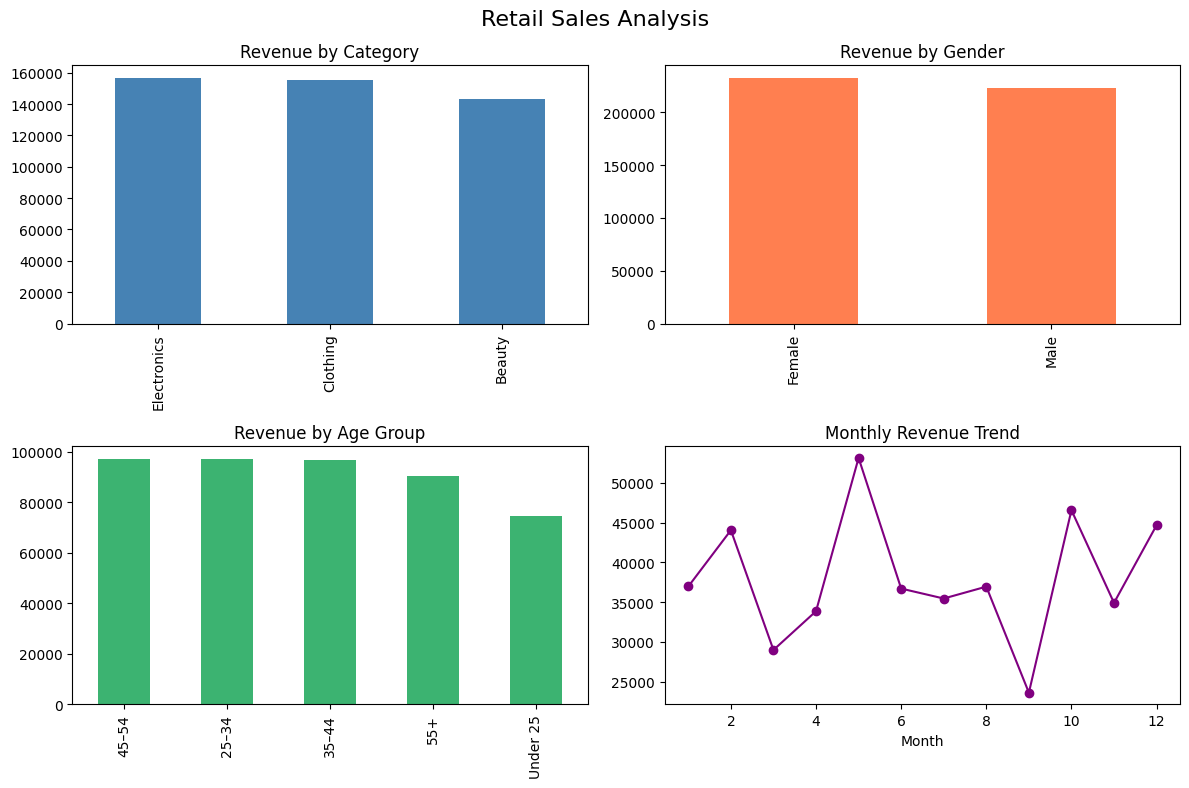

Chart saved!


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Retail Sales Analysis', fontsize=16)

# Category
category_sales.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Revenue by Category')
axes[0,0].set_xlabel('')

# Gender
category_gender.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Revenue by Gender')
axes[0,1].set_xlabel('')

# Age Group
category_age.plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Revenue by Age Group')
axes[1,0].set_xlabel('')

# Monthly
df.groupby('month')['total_amount'].sum().plot(kind='line', ax=axes[1,1], color='purple', marker='o')
axes[1,1].set_title('Monthly Revenue Trend')
axes[1,1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('sales_analysis.png')  # save the chart
plt.show()
print('Chart saved!')

In [25]:
from google.colab import files
files.download('sales_analysis.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>